# XGBoost на размеченных сообщениях

Ноутбук проверяет, как XGBoost работает на `data/labeling_sample.csv` с 10000 строками: подбирает разумный объем обучающих данных, запускает поиск гиперпараметров, строит кривые обучения и считает финальные метрики на отложенном тесте.

Если колонка `toxic` в этом файле еще не размечена вручную, ноутбук создаст слабую авторазметку по признакам `profanity_count`, `hostile_count` и `risk_score`.

In [16]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
MPLCONFIGDIR = DATA_DIR / '.matplotlib'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))
os.environ.setdefault('MPLBACKEND', 'Agg')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42
TRAINING_MESSAGES_PATH = DATA_DIR / 'labeling_sample.csv'

NUMERIC_FEATURES = [
    'risk_score',
    'char_len',
    'word_count',
    'profanity_count',
    'hostile_count',
    'exclamation_count',
    'question_count',
    'caps_ratio',
]
TEXT_FEATURE = 'text'
TARGET = 'toxic'


## 1. Загрузка и проверка данных

In [17]:
def add_weak_labels(df: pd.DataFrame) -> pd.DataFrame:
    required = {'risk_score', 'profanity_count', 'hostile_count'}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'Для авторазметки не хватает колонок: {missing}')

    result = df.copy()
    risk_score = pd.to_numeric(result['risk_score'], errors='coerce').fillna(0.0)
    profanity_count = pd.to_numeric(result['profanity_count'], errors='coerce').fillna(0)
    hostile_count = pd.to_numeric(result['hostile_count'], errors='coerce').fillna(0)

    risk_threshold = risk_score.quantile(0.8)
    bad_words_rule = (profanity_count > 0) | (hostile_count > 0)
    high_risk_rule = risk_score >= risk_threshold

    result[TARGET] = (bad_words_rule | high_risk_rule).astype(int)
    result['label_source'] = f'auto_rules: bad_words or risk_score >= {risk_threshold:.3f}'
    return result


def load_training_messages(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Не найден файл с разметкой: {path}')

    df = pd.read_csv(path)
    required = {TEXT_FEATURE, *NUMERIC_FEATURES}

    y = pd.to_numeric(df[TARGET], errors='coerce') if TARGET in df.columns else pd.Series([], dtype=float)
    if TARGET not in df.columns or not y.isin([0, 1]).any():
        df = add_weak_labels(df)
        y = pd.to_numeric(df[TARGET], errors='coerce')
    else:
        df = df[y.isin([0, 1])].copy()
    df[TARGET] = y[y.isin([0, 1])].astype(int)
    df[TEXT_FEATURE] = df[TEXT_FEATURE].fillna('').astype(str)
    df = df[df[TEXT_FEATURE].str.strip().ne('')].copy()

    for column in NUMERIC_FEATURES:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    return df.reset_index(drop=True)


labeled = load_training_messages(TRAINING_MESSAGES_PATH)
class_balance = labeled[TARGET].value_counts().sort_index().rename_axis(TARGET).reset_index(name='count')
class_balance['share'] = class_balance['count'] / len(labeled)

display(pd.DataFrame({'rows': [len(labeled)], 'columns': [labeled.shape[1]]}))
display(class_balance)
display(labeled[[TEXT_FEATURE, TARGET, *NUMERIC_FEATURES]].head())


,rows,columns
0,10000,20


,toxic,count,share
0,0,7867,0.7867
1,1,2133,0.2133


,text,toxic,risk_score,char_len,word_count,profanity_count,hostile_count,exclamation_count,question_count,caps_ratio
0,Бухать было ошибкой,0,0.176471,19,3,0,0,0,0,0.058824
1,Смекаешь,0,0.375000,8,1,0,0,0,0,0.125000
2,У вас вообще был конфетно букетный период?,0,0.285714,42,7,0,0,0,1,0.028571
3,сука,1,3.000000,4,1,1,0,0,0,0.000000
4,ты скрином?,0,0.200000,11,2,0,0,0,1,0.000000


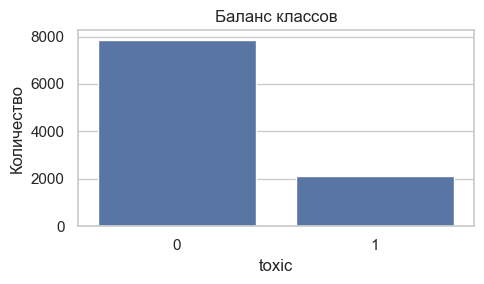

In [18]:
plt.figure(figsize=(5, 3))
sns.barplot(data=class_balance, x=TARGET, y='count')
plt.title('Баланс классов')
plt.xlabel('toxic')
plt.ylabel('Количество')
plt.tight_layout()


## 2. Holdout split и базовый pipeline

In [19]:
X = labeled[[TEXT_FEATURE, *NUMERIC_FEATURES]]
y = labeled[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

def make_preprocessor(max_features: int = 20000, ngram_range: tuple[int, int] = (1, 2)) -> ColumnTransformer:
    text_pipeline = TfidfVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
        max_features=max_features,
        sublinear_tf=True,
    )
    numeric_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ('text', text_pipeline, TEXT_FEATURE),
            ('num', numeric_pipeline, NUMERIC_FEATURES),
        ],
        sparse_threshold=0.3,
    )

def scale_pos_weight_for(y_values: pd.Series) -> float:
    counts = y_values.value_counts()
    return float(counts.get(0, 1) / max(counts.get(1, 1), 1))

def make_xgb_pipeline(
    *,
    scale_pos_weight: float | None = None,
    max_features: int = 20000,
    ngram_range: tuple[int, int] = (1, 2),
    **model_params,
) -> Pipeline:
    base_params = dict(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=250,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1,
    )
    if scale_pos_weight is not None:
        base_params['scale_pos_weight'] = scale_pos_weight
    base_params.update(model_params)

    return Pipeline(
        steps=[
            ('features', make_preprocessor(max_features=max_features, ngram_range=ngram_range)),
            ('model', XGBClassifier(**base_params)),
        ]
    )

print('Train:', X_train_full.shape, 'Test:', X_test.shape)
print('scale_pos_weight:', round(scale_pos_weight_for(y_train_full), 3))


Train: (8000, 9) Test: (2000, 9)
scale_pos_weight: 3.689


## 3. Подбор объема обучающих данных

Берем фиксированный holdout test, а внутри train подбираем размер подвыборки через stratified CV. Если размеченных данных меньше 10000, ноутбук автоматически использует все доступные строки.

In [20]:
def stratified_train_sample(X_data: pd.DataFrame, y_data: pd.Series, sample_size: int) -> tuple[pd.DataFrame, pd.Series]:
    sample_size = min(sample_size, len(y_data))
    if sample_size == len(y_data):
        return X_data.copy(), y_data.copy()
    _, X_sample, _, y_sample = train_test_split(
        X_data,
        y_data,
        test_size=sample_size,
        stratify=y_data,
        random_state=RANDOM_STATE,
    )
    return X_sample.copy(), y_sample.copy()

candidate_sizes = [200, 500, 1000, 2000, 5000, 10000]
candidate_sizes = sorted({size for size in candidate_sizes if size <= len(y_train_full)} | {len(y_train_full)})
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sample_rows = []
for sample_size in candidate_sizes:
    X_sample, y_sample = stratified_train_sample(X_train_full, y_train_full, sample_size)
    folds = min(5, y_sample.value_counts().min())
    local_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    estimator = make_xgb_pipeline(scale_pos_weight=scale_pos_weight_for(y_sample), n_estimators=180)
    scores = learning_curve(
        estimator,
        X_sample,
        y_sample,
        cv=local_cv,
        train_sizes=[1.0],
        scoring='f1',
        n_jobs=1,
    )
    _, train_scores, valid_scores = scores
    sample_rows.append(
        {
            'sample_size': len(y_sample),
            'train_f1_mean': train_scores.mean(),
            'train_f1_std': train_scores.std(),
            'cv_f1_mean': valid_scores.mean(),
            'cv_f1_std': valid_scores.std(),
            'positive_share': y_sample.mean(),
        }
    )

sample_size_results = pd.DataFrame(sample_rows).sort_values('sample_size')
best_cv_f1 = sample_size_results['cv_f1_mean'].max()
near_best = sample_size_results[sample_size_results['cv_f1_mean'] >= best_cv_f1 * 0.98]
selected_sample_size = int(near_best.iloc[0]['sample_size'])

display(sample_size_results)
print(f'Выбранный размер train для тюнинга: {selected_sample_size} из {len(y_train_full)}')


,sample_size,train_f1_mean,train_f1_std,cv_f1_mean,cv_f1_std,positive_share
0,200,1.0,0.0,1.0,0.0,0.21500
1,500,1.0,0.0,1.0,0.0,0.21400
2,1000,1.0,0.0,1.0,0.0,0.21300
3,2000,1.0,0.0,1.0,0.0,0.21300
4,5000,1.0,0.0,1.0,0.0,0.21320
5,8000,1.0,0.0,1.0,0.0,0.21325


Выбранный размер train для тюнинга: 200 из 8000


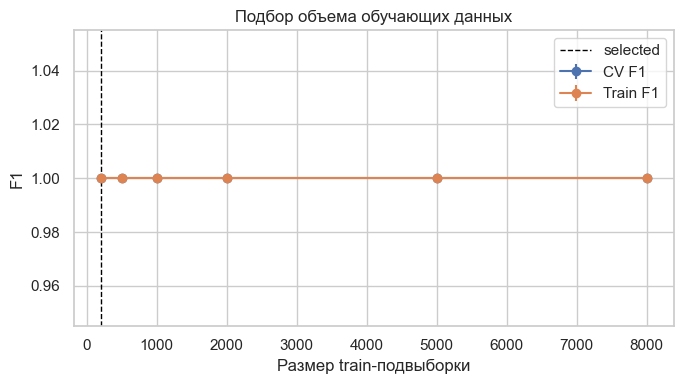

In [21]:
plt.figure(figsize=(7, 4))
plt.errorbar(
    sample_size_results['sample_size'],
    sample_size_results['cv_f1_mean'],
    yerr=sample_size_results['cv_f1_std'],
    marker='o',
    label='CV F1',
)
plt.errorbar(
    sample_size_results['sample_size'],
    sample_size_results['train_f1_mean'],
    yerr=sample_size_results['train_f1_std'],
    marker='o',
    label='Train F1',
)
plt.axvline(selected_sample_size, color='black', linestyle='--', linewidth=1, label='selected')
plt.title('Подбор объема обучающих данных')
plt.xlabel('Размер train-подвыборки')
plt.ylabel('F1')
plt.legend()
plt.tight_layout()


## 4. Подбор гиперпараметров XGBoost

In [22]:
X_tune, y_tune = stratified_train_sample(X_train_full, y_train_full, selected_sample_size)
tune_cv = StratifiedKFold(n_splits=min(5, y_tune.value_counts().min()), shuffle=True, random_state=RANDOM_STATE)

search_pipeline = make_xgb_pipeline(scale_pos_weight=scale_pos_weight_for(y_tune))
param_distributions = {
    'features__text__max_features': randint(3000, 25001),
    'features__text__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'model__n_estimators': randint(120, 601),
    'model__max_depth': randint(2, 7),
    'model__learning_rate': uniform(0.02, 0.16),
    'model__subsample': uniform(0.65, 0.35),
    'model__colsample_bytree': uniform(0.65, 0.35),
    'model__min_child_weight': randint(1, 8),
    'model__reg_alpha': uniform(0.0, 1.0),
    'model__reg_lambda': uniform(0.5, 3.0),
}

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
    refit='f1',
    cv=tune_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True,
)

search.fit(X_tune, y_tune)

cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_f1')
display(cv_results[[
    'rank_test_f1',
    'mean_test_f1',
    'std_test_f1',
    'mean_test_roc_auc',
    'mean_train_f1',
    'params',
]].head(10))
search.best_params_


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,rank_test_f1,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_train_f1,params
0,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 18795, 'features__text__ngram_range': (1, 1), 'model__colsample_bytree': 0.71420217..."
1,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 14363, 'features__text__ngram_range': (1, 3), 'model__colsample_bytree': 0.65720457..."
2,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 22769, 'features__text__ngram_range': (1, 2), 'model__colsample_bytree': 0.65247320..."
3,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 22118, 'features__text__ngram_range': (1, 2), 'model__colsample_bytree': 0.71988582..."
4,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 11792, 'features__text__ngram_range': (1, 2), 'model__colsample_bytree': 0.93293907..."
5,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 20159, 'features__text__ngram_range': (1, 3), 'model__colsample_bytree': 0.71067762..."
6,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 12692, 'features__text__ngram_range': (1, 3), 'model__colsample_bytree': 0.94479967..."
7,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 4016, 'features__text__ngram_range': (1, 2), 'model__colsample_bytree': 0.763865615..."
8,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 10208, 'features__text__ngram_range': (1, 1), 'model__colsample_bytree': 0.93076894..."
9,1,1.0,0.0,1.0,1.0,"{'features__text__max_features': 16986, 'features__text__ngram_range': (1, 3), 'model__colsample_bytree': 0.91994462..."


{'features__text__max_features': 18795,
 'features__text__ngram_range': (1, 1),
 'model__colsample_bytree': np.float64(0.7142021764531573),
 'model__learning_rate': np.float64(0.1447505600436431),
 'model__max_depth': 6,
 'model__min_child_weight': 7,
 'model__n_estimators': 241,
 'model__reg_alpha': np.float64(0.15599452033620265),
 'model__reg_lambda': np.float64(0.6742508365045984),
 'model__subsample': np.float64(0.9531616510212273)}

## 5. Финальное обучение и метрики на test

In [23]:
best_model = search.best_estimator_
best_model.fit(X_train_full, y_train_full)

y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame(
    [
        {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_score),
        }
    ]
)

display(final_metrics)
print(classification_report(y_test, y_pred, digits=3))


,accuracy,precision,recall,f1,roc_auc
0,1.0,1.0,1.0,1.0,1.0


              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1573
           1      1.000     1.000     1.000       427

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



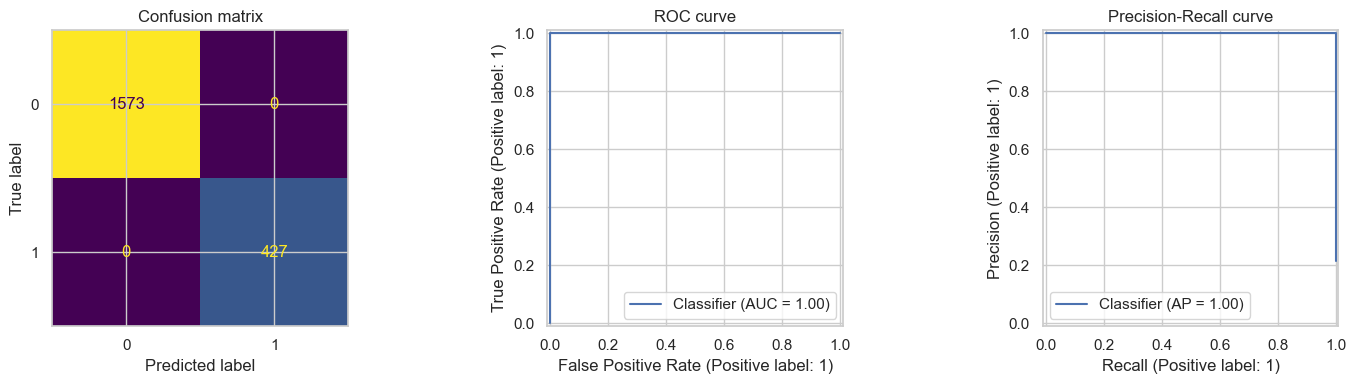

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix')

RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[2])
axes[2].set_title('Precision-Recall curve')

plt.tight_layout()


## 6. Кривые обучения

In [25]:
train_sizes_abs, train_scores_f1, valid_scores_f1 = learning_curve(
    best_model,
    X_train_full,
    y_train_full,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='f1',
    n_jobs=1,
)

_, train_scores_auc, valid_scores_auc = learning_curve(
    best_model,
    X_train_full,
    y_train_full,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='roc_auc',
    n_jobs=1,
)

learning_curve_results = pd.DataFrame(
    {
        'train_size': train_sizes_abs,
        'train_f1_mean': train_scores_f1.mean(axis=1),
        'train_f1_std': train_scores_f1.std(axis=1),
        'cv_f1_mean': valid_scores_f1.mean(axis=1),
        'cv_f1_std': valid_scores_f1.std(axis=1),
        'train_roc_auc_mean': train_scores_auc.mean(axis=1),
        'train_roc_auc_std': train_scores_auc.std(axis=1),
        'cv_roc_auc_mean': valid_scores_auc.mean(axis=1),
        'cv_roc_auc_std': valid_scores_auc.std(axis=1),
    }
)
learning_curve_results


,train_size,train_f1_mean,train_f1_std,cv_f1_mean,cv_f1_std,train_roc_auc_mean,train_roc_auc_std,cv_roc_auc_mean,cv_roc_auc_std
0,1280,1.0,0.0,1.0,0.0,1.0,0.000000e+00,1.0,4.965068e-17
1,2560,1.0,0.0,1.0,0.0,1.0,0.000000e+00,1.0,0.000000e+00
2,3840,1.0,0.0,1.0,0.0,1.0,0.000000e+00,1.0,4.965068e-17
3,5120,1.0,0.0,1.0,0.0,1.0,4.965068e-17,1.0,0.000000e+00
4,6400,1.0,0.0,1.0,0.0,1.0,4.965068e-17,1.0,0.000000e+00


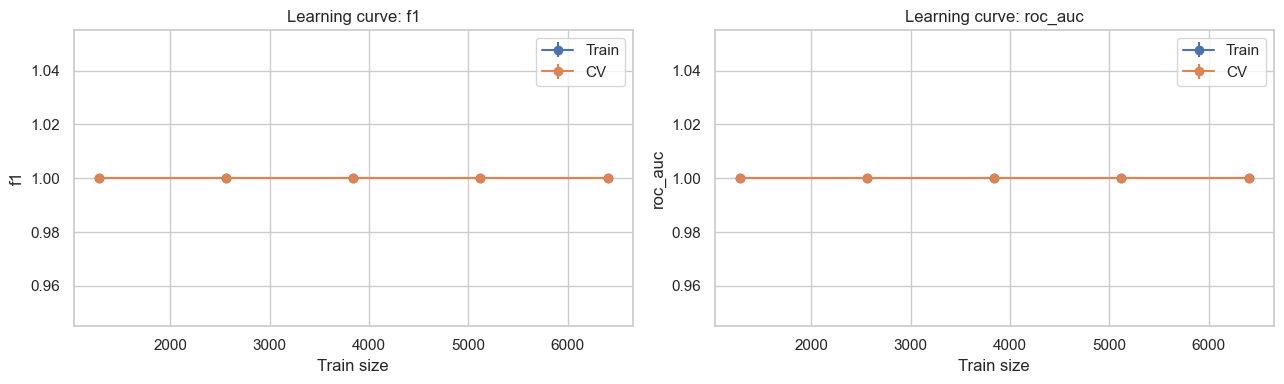

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric in zip(axes, ['f1', 'roc_auc']):
    ax.errorbar(
        learning_curve_results['train_size'],
        learning_curve_results[f'train_{metric}_mean'],
        yerr=learning_curve_results[f'train_{metric}_std'],
        marker='o',
        label='Train',
    )
    ax.errorbar(
        learning_curve_results['train_size'],
        learning_curve_results[f'cv_{metric}_mean'],
        yerr=learning_curve_results[f'cv_{metric}_std'],
        marker='o',
        label='CV',
    )
    ax.set_title(f'Learning curve: {metric}')
    ax.set_xlabel('Train size')
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()


## 7. Важность признаков

,feature,importance
2342,num__risk_score,0.314376
2349,num__caps_ratio,0.306507
2345,num__profanity_count,0.277911
2346,num__hostile_count,0.037394
219,text__бля,0.017769
2347,num__exclamation_count,0.009853
1376,text__пиздец,0.008746
95,text__mention,0.007891
223,text__блять,0.007464
2216,text__хуй,0.006759


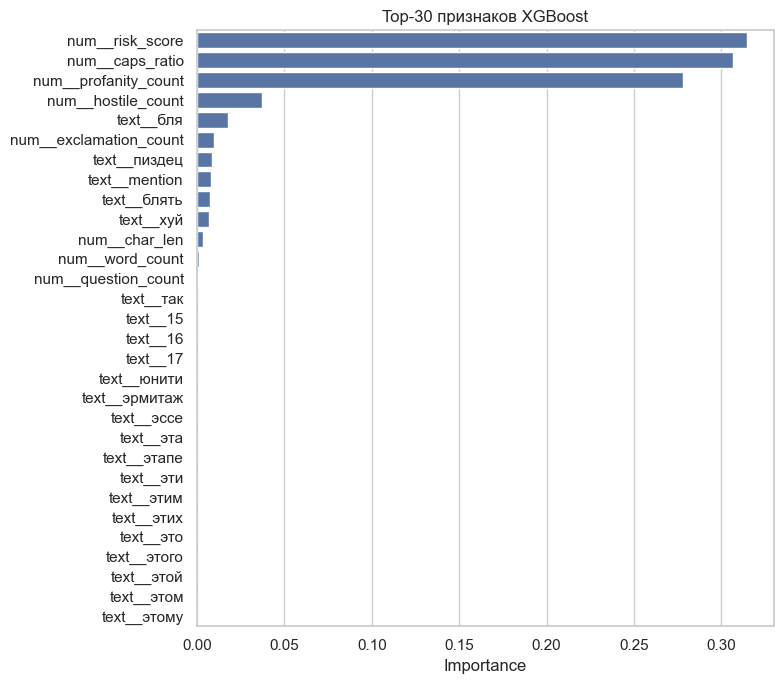

In [27]:
feature_names = best_model.named_steps['features'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_
feature_importance = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(30)
)

display(feature_importance)

plt.figure(figsize=(8, 7))
sns.barplot(data=feature_importance, y='feature', x='importance')
plt.title('Top-30 признаков XGBoost')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
